## Downloading Dataset

#### resolve csv.gz.icloud issue after downloading files from google drive using gdown

To download the files use the following commands:

```
pip install gdown

gdown --folder --id 1lHg9ryOGtWuQjIULlrjDFbThfDNc44Y-
```

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import pandas as pd

import os
print('-'*40, 'hosp', '-'*40)
path = "./dataset/mimic4/hosp"
for i in os.listdir(path):
    print(i)
print('-'*40, 'icu', '-'*40)
path = "./dataset/mimic4/icu"
for i in os.listdir(path):
    print(i)

---------------------------------------- hosp ----------------------------------------
admissions.csv.gz
diagnoses_icd.csv.gz
drgcodes.csv.gz
d_hcpcs.csv.gz
d_icd_diagnoses.csv.gz
d_icd_procedures.csv.gz
d_labitems.csv.gz
emar.csv.gz
emar_detail.csv.gz
hcpcsevents.csv.gz
labevents.csv.gz
microbiologyevents.csv.gz
omr.csv.gz
patients.csv.gz
pharmacy.csv.gz
poe.csv.gz
poe_detail.csv.gz
prescriptions.csv.gz
procedures_icd.csv.gz
services.csv.gz
transfers.csv.gz
---------------------------------------- icu ----------------------------------------
chartevents.csv.gz
datetimeevents.csv.gz
d_items.csv.gz
icustays.csv.gz
ingredientevents.csv.gz
outputevents.csv.gz
procedureevents.csv.gz


In [ ]:
# Core demographic and admission data
patients = pd.read_csv("dataset/mimic4/hosp/patients.csv.gz")
admissions = pd.read_csv("dataset/mimic4/hosp/admissions.csv.gz")

# ICU stays
icustays = pd.read_csv("dataset/mimic4/icu/icustays.csv.gz")

# Diagnoses (optional but useful)
diagnoses = pd.read_csv("dataset/mimic4/hosp/diagnoses_icd.csv.gz")

# Dictionaries for interpretation
d_items = pd.read_csv("dataset/mimic4/icu/d_items.csv.gz")
d_labitems = pd.read_csv("dataset/mimic4/hosp/d_labitems.csv.gz")


In [3]:
# bigger files

# Charted ICU data (vitals)
# cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'valuenum']
# chartevents = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols)
# import after d_items dataframe is being cleaned

# Lab tests
cols = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum']
#labevents = pd.read_csv("./dataset/mimic4//hosp/labevents.csv.gz", usecols=cols)
chunks = pd.read_csv("./dataset/mimic4/hosp/labevents.csv.gz", usecols=cols, chunksize=300000, low_memory=False)
labevents = pd.concat(chunks)


## Preprocessing

### patients

Rows: 1 per patient

KeyID: `subject_id`

| Column      | Type       | Description                                              |
|------------|-----------|----------------------------------------------------------|
| `subject_id`  | ID        | Unique patient ID                                      |
| `gender`      | 🔒 Sensitive | Male or Female                                       |
| `anchor_age`  | 🔒 Sensitive | Approximate age at time of admission                |
| `dod`         | 🧠 Label   | Date of death (used with ICU discharge to define ICU mortality) |


In [4]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [5]:
print(f'''patients:
{patients.shape}
{'-'*20}
{patients.dtypes}
{'-'*20}
{patients.count()}
{'-'*20}
{patients.isna().sum()}
{'-'*20}
{patients.describe()}
{'-'*20}
''')

patients:
(364627, 6)
--------------------
subject_id            int64
gender               object
anchor_age            int64
anchor_year           int64
anchor_year_group    object
dod                  object
dtype: object
--------------------
subject_id           364627
gender               364627
anchor_age           364627
anchor_year          364627
anchor_year_group    364627
dod                   38301
dtype: int64
--------------------
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  326326
dtype: int64
--------------------
         subject_id     anchor_age    anchor_year
count  3.646270e+05  364627.000000  364627.000000
mean   1.501166e+07      48.875097    2150.835404
std    2.885013e+06      20.943316      23.395666
min    1.000003e+07      18.000000    2110.000000
25%    1.251201e+07      29.000000    2131.000000
50%    1.501868e+07      48.000000    2151.000000


In [6]:
# Drop synthetic time columns
patients_clean = patients.copy()
patients_clean = patients_clean.drop(columns=['anchor_year', 'anchor_year_group'])

# Convert gender to binary
patients_clean['gender'] = patients_clean['gender'].map({'M': 1, 'F': 0})

# Convert dod to datetime
patients_clean['dod'] = pd.to_datetime(patients_clean['dod'])

# dod will have many missing values — that’s expected (most patients survived)
print(f'''patients_clean:
{patients_clean.shape}
{'-'*40}
{patients_clean.count()}
{'-'*40}
{patients_clean.isna().sum()}
{'-'*40}
''')
patients_clean.info()
patients_clean.head()

patients_clean:
(364627, 4)
----------------------------------------------------------------------------------------------------
subject_id    364627
gender        364627
anchor_age    364627
dod            38301
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id         0
gender             0
anchor_age         0
dod           326326
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   subject_id  364627 non-null  int64         
 1   gender      364627 non-null  int64         
 2   anchor_age  364627 non-null  int64         
 3   dod         38301 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 11.1 MB


,subject_id,gender,anchor_age,dod
0,10000032,0,52,2180-09-09
1,10000048,0,23,NaT
2,10000058,0,33,NaT
3,10000068,0,19,NaT
4,10000084,1,72,2161-02-13


minimum age: 18
maximum age: 91
unique values: 73
Age groups:
['50-64' '18-29' '30-49' '65-79' '80-91']
             Count  Percentage (%)
age_grouped                       
18-29        91967           25.22
30-49        96157           26.37
50-64        80788           22.16
65-79        61698           16.92
80-91        34017            9.33


C:\Users\Cynthia\AppData\Local\Temp\ipykernel_20372\1259842300.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{count}\n({age_stats['Percentage (%)'][i]}%)",


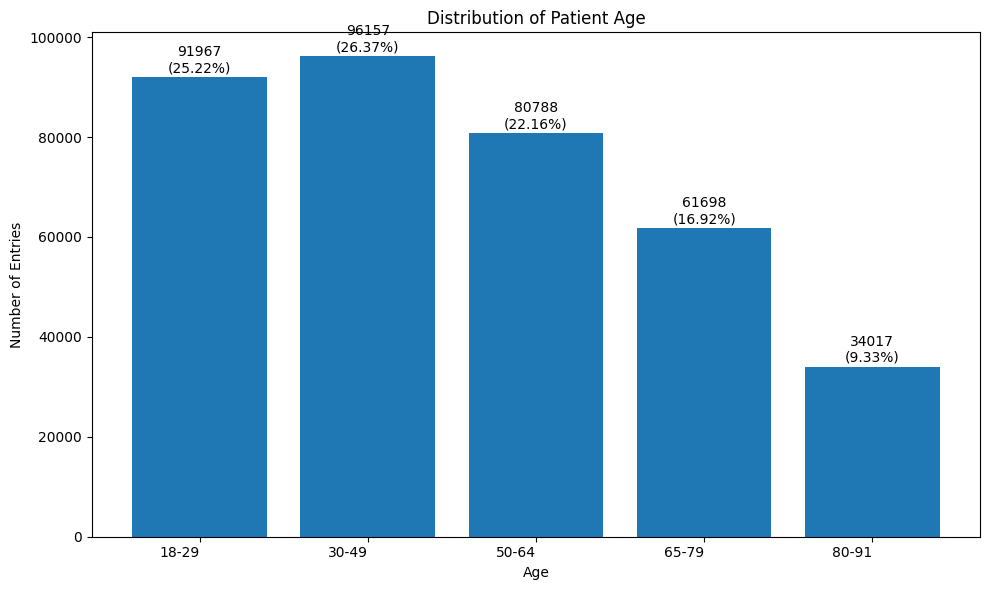

Original shape: (364627, 5)
Encoded shape: (364627, 8)


In [79]:
# Convert age to age groups and apply one-hot encoding
print(f"minimum age: {patients_clean['anchor_age'].min()}")
print(f"maximum age: {patients_clean['anchor_age'].max()}")
print(f"unique values: {patients_clean['anchor_age'].nunique()}")

def map_age(age_value):
    if age_value < 30:
        return "18-29"
    elif age_value < 50:
        return "30-49"
    elif age_value < 65:
        return "50-64"
    elif age_value < 80:
        return "65-79"
    else:
        return "80-91"

patients_clean['age_grouped'] = patients_clean['anchor_age'].apply(map_age)
print(f"Age groups:\n{patients_clean['age_grouped'].unique()}")
# Count entries for each consolidated category
age_order = ["18-29", "30-49", "50-64", "65-79", "80-91"]
age_group_counts = patients_clean['age_grouped'].value_counts().reindex(age_order)
# Get percentage of each category
age_percentages = (age_group_counts / len(patients_clean) * 100).round(2)
age_stats = pd.DataFrame({
        'Count': age_group_counts,
        'Percentage (%)': age_percentages
    })
print(age_stats)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(age_stats.index, age_stats['Count'])
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Entries')
plt.xticks(ha='right')
plt.tight_layout()

# Add count labels above bars
for i, count in enumerate(age_stats['Count']):
    plt.text(i, count + (max(age_stats['Count'])*0.01), 
                f"{count}\n({age_stats['Percentage (%)'][i]}%)", 
                ha='center')
plt.show()

# Using sklearn OneHotEncoder to apply one-hot encoding
# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Reshape the race column and fit transform
age_array = encoder.fit_transform(patients_clean[['age_grouped']])

# Create a DataFrame with the encoded values
age_encoded_df = pd.DataFrame(
    age_array, 
    columns=[f'age_{age}' for age in encoder.categories_[0]],
    index=patients_clean.index
)

# Concatenate with original dataframe
patients_encoded = pd.concat([patients_clean, age_encoded_df], axis=1)

# drop the original race columns
patients_encoded = patients_encoded.drop(['anchor_age', 'age_grouped'], axis=1)

# Display the shape of the new dataframe
print(f"Original shape: {patients_clean.shape}")
print(f"Encoded shape: {patients_encoded.shape}")


### admissions

Rows: 1 per hospital admission(hadm_id)

Key IDs: `subject_id`, `hadm_id`

| Column                  | Type                 | Description                                           |
|-------------------------|----------------------|-------------------------------------------------------|
| `subject_id`           | ID                   | Patient ID                                           |
| `hadm_id`             | ID                   | Hospital admission ID                                |
| `ethnicity`           | 🔒 Sensitive         | Patient-reported race/ethnicity                     |
| `insurance`           | 🔒 Sensitive         | Primary insurance type (e.g., Medicaid, Private)    |
| `language`            | 🔒 Sensitive         | Preferred language                                  |
| `marital_status`      | 🔒 Sensitive         | Married, Single, Divorced, etc.                     |
| `admittime / dischtime` | 🧠 Predictive (optional) | Can be used to compute hospital LOS (length of stay) |


In [7]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [8]:
print(f'''admissions:
{admissions.shape}
{'-'*20}
{admissions.dtypes}
{'-'*20}
{admissions.count()}
{'-'*20}
{admissions.isna().sum()}
{'-'*20}
{admissions.describe()}
{'-'*20}
''')

admissions:
(546028, 16)
--------------------
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object
--------------------
subject_id              546028
hadm_id                 546028
admittime               546028
dischtime               546028
deathtime                11790
admission_type          546028
admit_provider_id       546024
admission_location      546027
discharge_location      396210
insurance               536673
language                545253
marital_status          532409
race                    546028
edregtime           

In [35]:
admissions_clean['language'].unique()
admissions_clean['race'].unique()

# Language, insurance, Marital status is removed first to see how it goes
# We'll be analyzing sensitive attributes based on age, gender and race at this time
# race will be consolidated and encoded in one-hot encoding

array(['WHITE', 'OTHER', 'BLACK/AFRICAN AMERICAN', 'UNABLE TO OBTAIN',
       'UNKNOWN', 'WHITE - RUSSIAN', 'BLACK/CAPE VERDEAN',
       'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'PORTUGUESE',
       'WHITE - OTHER EUROPEAN', 'HISPANIC/LATINO - PUERTO RICAN',
       'ASIAN', 'ASIAN - CHINESE', 'HISPANIC/LATINO - DOMINICAN',
       'HISPANIC/LATINO - SALVADORAN', 'BLACK/AFRICAN',
       'HISPANIC/LATINO - GUATEMALAN', 'ASIAN - SOUTH EAST ASIAN',
       'WHITE - BRAZILIAN', 'SOUTH AMERICAN', 'HISPANIC OR LATINO',
       'ASIAN - KOREAN', 'BLACK/CARIBBEAN ISLAND',
       'HISPANIC/LATINO - MEXICAN', 'PATIENT DECLINED TO ANSWER',
       'HISPANIC/LATINO - CUBAN', 'AMERICAN INDIAN/ALASKA NATIVE',
       'MULTIPLE RACE/ETHNICITY', 'WHITE - EASTERN EUROPEAN',
       'HISPANIC/LATINO - HONDURAN', 'HISPANIC/LATINO - CENTRAL AMERICAN',
       'ASIAN - ASIAN INDIAN', 'HISPANIC/LATINO - COLUMBIAN'],
      dtype=object)

In [51]:
cols = ['subject_id', 'hadm_id', 'admittime', 'dischtime',
             # 'insurance', 'language', 'marital_status',
             'race','hospital_expire_flag', 'admission_type']

admissions_clean = admissions[cols].copy()

# Convert datetime columns
admissions_clean['admittime'] = pd.to_datetime(admissions_clean['admittime'])
admissions_clean['dischtime'] = pd.to_datetime(admissions_clean['dischtime'])

# Fill missing values for sensitive attributes
'''“This particular NaN value has special meaning — it tells us that the information was unknown or missing at the time. 
Instead of dropping or guessing it, we treat it as its own category by converting it into a label like 'UNKNOWN', so the model can process it.”'''
# admissions_clean[['insurance', 'language', 'marital_status']] = admissions_clean[['insurance', 'language', 'marital_status']].fillna('UNKNOWN')

# Preview cleaned data
admissions_clean.info()
admissions_clean.head()

admissions_clean:
(546028, 7)
----------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   subject_id            546028 non-null  int64         
 1   hadm_id               546028 non-null  int64         
 2   admittime             546028 non-null  datetime64[ns]
 3   dischtime             546028 non-null  datetime64[ns]
 4   race                  546028 non-null  object        
 5   hospital_expire_flag  546028 non-null  int64         
 6   admission_type        546028 non-null  object        
dtypes: datetime64[ns](2), int64(3), object(2)
memory usage: 29.2+ MB


,subject_id,hadm_id,admittime,dischtime,race,hospital_expire_flag,admission_type
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,WHITE,0,URGENT
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,WHITE,0,EW EMER.
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,WHITE,0,EW EMER.
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,WHITE,0,EW EMER.
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,WHITE,0,EU OBSERVATION


Consolidated races:
['WHITE' 'OTHER' 'BLACK' 'RUSSIAN' 'NATIVE AMERICANS' 'PORTUGUESE'
 'EUROPEAN' 'HISPANIC/LATINO' 'ASIAN' 'SOUTH AMERICAN'
 'MULTIPLE RACE/ETHNICITY']
                          Count  Percentage (%)
race_consolidated                              
WHITE                    338064           61.91
BLACK                     89057           16.31
OTHER                     39298            7.20
HISPANIC/LATINO           32210            5.90
ASIAN                     19751            3.62
EUROPEAN                  15858            2.90
RUSSIAN                    6597            1.21
PORTUGUESE                 2082            0.38
NATIVE AMERICANS           1741            0.32
SOUTH AMERICAN              774            0.14
MULTIPLE RACE/ETHNICITY     596            0.11


C:\Users\Cynthia\AppData\Local\Temp\ipykernel_20372\3621940416.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"{count}\n({race_stats['Percentage (%)'][i]}%)",


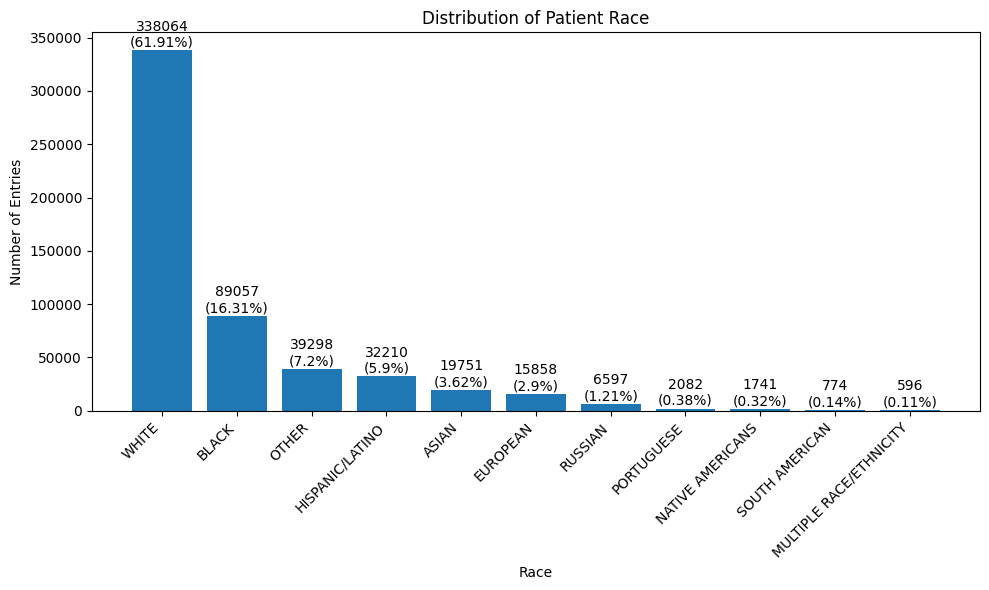

Original shape: (546028, 8)
Encoded shape: (546028, 17)


In [64]:
def map_race(race_value):
    if pd.isna(race_value):
        return 'UNKNOWN'
    elif 'RUSSIAN' in race_value:
        return 'RUSSIAN'
    elif 'EUROPEAN' in race_value:
        return 'EUROPEAN'
    elif 'WHITE' in race_value:
        return 'WHITE'
    elif 'ASIAN' in race_value:
        return 'ASIAN'
    elif 'HISPANIC/LATINO' in race_value:
        return 'HISPANIC/LATINO'
    elif 'HISPANIC OR LATINO' in race_value:
        return 'HISPANIC/LATINO'
    elif race_value in ['PATIENT DECLINED TO ANSWER', 'UNABLE TO OBTAIN', 'UNKNOWN']:
        return 'OTHER'
    elif 'BLACK' in race_value:
        return 'BLACK'
    elif race_value in ['AMERICAN INDIAN/ALASKA NATIVE', 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER']:
        return 'NATIVE AMERICANS'
    else:
        return race_value

admissions_clean['race_consolidated'] = admissions_clean['race'].apply(map_race)
print(f"Consolidated races:\n{admissions_clean['race_consolidated'].unique()}")
# Count entries for each consolidated category
race_counts = admissions_clean['race_consolidated'].value_counts()
# Get percentage of each category
race_percentages = (race_counts / len(admissions_clean) * 100).round(2)
race_stats = pd.DataFrame({
        'Count': race_counts,
        'Percentage (%)': race_percentages
    })
print(race_stats)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(race_stats.index, race_stats['Count'])
plt.title('Distribution of Patient Race')
plt.xlabel('Race')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add count labels above bars
for i, count in enumerate(race_stats['Count']):
    plt.text(i, count + (max(race_stats['Count'])*0.01), 
                f"{count}\n({race_stats['Percentage (%)'][i]}%)", 
                ha='center')
plt.show()

# Using sklearn OneHotEncoder to apply one-hot encoding
# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Reshape the race column and fit transform
race_array = encoder.fit_transform(admissions_clean[['race_consolidated']])

# Create a DataFrame with the encoded values
race_encoded_df = pd.DataFrame(
    race_array, 
    columns=[f'race_{race}' for race in encoder.categories_[0]],
    index=admissions_clean.index
)

# Concatenate with original dataframe
admissions_encoded = pd.concat([admissions_clean, race_encoded_df], axis=1)

# drop the original race columns
admissions_encoded = admissions_encoded.drop(['race', 'race_consolidated'], axis=1)

# Display the shape of the new dataframe
print(f"Original shape: {admissions_clean.shape}")
print(f"Encoded shape: {admissions_encoded.shape}")

### icustays

Rows: 1 per ICU stay

Key IDs: `subject_id`, `hadm_id`, `stay_id`

| Column      | Type             | Description                                                        |
|-------------|------------------|--------------------------------------------------------------------|
| subject_id  | ID               | Patient ID                                                         |
| hadm_id     | ID               | Hospital admission ID                                              |
| stay_id     | ID               | ICU stay ID                                                        |
| intime      | 🔮 Predictive    | ICU admission timestamp                                            |
| outtime     | 🔮 Predictive & Label | ICU discharge timestamp; used with `dod` to compute ICU mortality (`dod ≤ outtime`) |

In [10]:
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [11]:
print(f'''icustays:
{icustays.shape}
{'-'*20}
{icustays.dtypes}
{'-'*20}
{icustays.count()}
{'-'*20}
{icustays.isna().sum()}
{'-'*20}
{icustays.describe()}
{'-'*20}
''')

icustays:
(94458, 8)
--------------------
subject_id          int64
hadm_id             int64
stay_id             int64
first_careunit     object
last_careunit      object
intime             object
outtime            object
los               float64
dtype: object
--------------------
subject_id        94458
hadm_id           94458
stay_id           94458
first_careunit    94458
last_careunit     94458
intime            94458
outtime           94444
los               94444
dtype: int64
--------------------
subject_id         0
hadm_id            0
stay_id            0
first_careunit     0
last_careunit      0
intime             0
outtime           14
los               14
dtype: int64
--------------------
         subject_id       hadm_id       stay_id           los
count  9.445800e+04  9.445800e+04  9.445800e+04  94444.000000
mean   1.500422e+07  2.498185e+07  3.499832e+07      3.630025
std    2.884050e+06  2.884066e+06  2.886407e+06      5.402474
min    1.000003e+07  2.000009e+07  3.00

In [52]:
'''Don't use los for ICU mortality prediction because it creates a leakage risk.
If someone dies early, their los will be very short → model might learn to predict death from low los directly.
You want to predict it based on vitals, labs, and demographics available early, so use los for descriptive statistics and filtering out noise'''


# You can’t define ICU mortality without outtime so drop those missing rows
# Drops entire rows where the column outtime is NaN
icustays_clean = icustays.copy()
icustays_clean = icustays_clean.dropna(subset=['outtime'])

# Convert intime and outtime to datetime
icustays_clean['intime'] = pd.to_datetime(icustays_clean['intime'])
icustays_clean['outtime'] = pd.to_datetime(icustays_clean['outtime'])

cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'los', 'first_careunit']
icustays_clean = icustays_clean[cols]

# Preview cleaned data
icustays_clean.info()
icustays_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 94444 entries, 0 to 94457
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   subject_id      94444 non-null  int64         
 1   hadm_id         94444 non-null  int64         
 2   stay_id         94444 non-null  int64         
 3   intime          94444 non-null  datetime64[ns]
 4   outtime         94444 non-null  datetime64[ns]
 5   los             94444 non-null  float64       
 6   first_careunit  94444 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(3), object(1)
memory usage: 5.8+ MB


,subject_id,hadm_id,stay_id,intime,outtime,los,first_careunit
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,Medical Intensive Care Unit (MICU)
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,Medical Intensive Care Unit (MICU)
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,Medical Intensive Care Unit (MICU)
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,Surgical Intensive Care Unit (SICU)
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,Surgical Intensive Care Unit (SICU)


### diagnoses

Rows: 1 per diagnosis

Key IDs: `subject_id`, `hadm_id`

| Column      | Type             | Description         |
|-------------|------------------|---------------------|
| subject_id  | ID               | Patient ID            |
| hadm_id     | ID               | Hospital admission ID             |
| seq_num     | label       |A pseudo-order for the ICD codes within a stay (1 most relevant, 9 the least)  |
| icd_code      | label    | The coded representation of the diagnosis using the ICD ontology      |
| icd_version   | label | The textual description of the ICD code |

In [13]:
diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [14]:
print(f'''diagnoses:
{diagnoses.shape}
{'-'*20}
{diagnoses.dtypes}
{'-'*20}
{diagnoses.count()}
{'-'*20}
{diagnoses.isna().sum()}
{'-'*20}
{diagnoses.describe()}
{'-'*20}
''')

diagnoses:
(6364488, 5)
--------------------
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object
--------------------
subject_id     6364488
hadm_id        6364488
seq_num        6364488
icd_code       6364488
icd_version    6364488
dtype: int64
--------------------
subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64
--------------------
         subject_id       hadm_id       seq_num   icd_version
count  6.364488e+06  6.364488e+06  6.364488e+06  6.364488e+06
mean   1.500237e+07  2.500059e+07  8.825529e+00  9.542973e+00
std    2.878400e+06  2.889094e+06  6.858762e+00  4.981499e-01
min    1.000003e+07  2.000002e+07  1.000000e+00  9.000000e+00
25%    1.251032e+07  2.249520e+07  4.000000e+00  9.000000e+00
50%    1.500206e+07  2.500402e+07  7.000000e+00  1.000000e+01
75%    1.750180e+07  2.750210e+07  1.200000e+01  1.000000e+01
max    1.999999e+07  2.999994e+07  3.900000e+0

In [15]:
# Charlson/Elixhauser handle ICD-9 only — pre-filter ICD-9 to exclude ICD-10
diagnoses_clean = diagnoses[diagnoses['icd_version'] == 9].copy()

cols = ['subject_id', 'hadm_id', 'icd_code']
diagnoses_clean = diagnoses_clean[cols]

# Convert icd_code to string and standardize format
diagnoses_clean = diagnoses_clean[cols]
diagnoses_clean['icd_code'] = diagnoses_clean['icd_code'].astype(str).str.strip().str.upper()

# Preview cleaned data
diagnoses_clean.info()
diagnoses_clean.head()

diagnoses_clean:
(2908741, 3)
----------------------------------------------------------------------------------------------------
subject_id    2908741
hadm_id       2908741
icd_code      2908741
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id    0
hadm_id       0
icd_code      0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 2908741 entries, 0 to 6364487
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   subject_id  int64 
 1   hadm_id     int64 
 2   icd_code    object
dtypes: int64(2), object(1)
memory usage: 88.8+ MB


,subject_id,hadm_id,icd_code
0,10000032,22595853,5723
1,10000032,22595853,78959
2,10000032,22595853,5715
3,10000032,22595853,07070
4,10000032,22595853,496


### labevents

Rows: Time-stamped lab measurements

Key IDs: `subject_id`, `hadm_id`

| Column                | Type          | Description                                      |
|-----------------------|---------------|--------------------------------------------------|
| subject_id, hadm_id   | ID            | For joining and grouping                         |
| itemid                | Lookup        | Lab test code (mapped via `d_labitems.csv.gz`)   |
| charttime             | Time          | When the lab was drawn                           |
| valuenum              | 🔮 Predictive  | Numeric result (e.g., WBC = 12.3)                |

In [16]:
labevents.head()

,subject_id,hadm_id,itemid,charttime,valuenum
0,10000032,NaN,50931,2180-03-23 11:51:00,95.0
1,10000032,NaN,51071,2180-03-23 11:51:00,NaN
2,10000032,NaN,51074,2180-03-23 11:51:00,NaN
3,10000032,NaN,51075,2180-03-23 11:51:00,NaN
4,10000032,NaN,51079,2180-03-23 11:51:00,NaN


In [17]:
print(f'''labevents:
{labevents.shape}
{'-'*20}
{labevents.dtypes}
{'-'*20}
{labevents.count()}
{'-'*20}
{labevents.isna().sum()}
{'-'*20}
{labevents["valuenum"].describe()}
{'-'*20}
''')

labevents:
(158374764, 5)
--------------------
subject_id      int64
hadm_id       float64
itemid          int64
charttime      object
valuenum      float64
dtype: object
--------------------
subject_id    158374764
hadm_id        84605867
itemid        158374764
charttime     158374764
valuenum      136884423
dtype: int64
--------------------
subject_id           0
hadm_id       73768897
itemid               0
charttime            0
valuenum      21490341
dtype: int64
--------------------
count    1.368844e+08
mean     6.882403e+01
std      2.885397e+03
min     -1.444000e+03
25%      3.700000e+00
50%      1.400000e+01
75%      4.490000e+01
max      6.905000e+06
Name: valuenum, dtype: float64
--------------------



In [80]:
# Drop rows without numeric values (non-numeric test results)
labevents_clean = labevents.dropna(subset=['valuenum']).copy()
labevents_clean['charttime'] = pd.to_datetime(labevents_clean['charttime'])

# Preview cleaned data
labevents_clean.info()
labevents_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 136884423 entries, 0 to 158374763
Data columns (total 5 columns):
 #   Column      Dtype         
---  ------      -----         
 0   subject_id  int64         
 1   hadm_id     float64       
 2   itemid      int64         
 3   charttime   datetime64[ns]
 4   valuenum    float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 6.1 GB


,subject_id,hadm_id,itemid,charttime,valuenum
0,10000032,NaN,50931,2180-03-23 11:51:00,95.0
9,10000032,NaN,50853,2180-03-23 11:51:00,15.0
10,10000032,NaN,50861,2180-03-23 11:51:00,102.0
11,10000032,NaN,50862,2180-03-23 11:51:00,3.3
12,10000032,NaN,50863,2180-03-23 11:51:00,109.0


### d_items

Rows: One per itemid(dictionary)

Key: `itemid`

| Column   | Type              | Description                                              |
|----------|-------------------|----------------------------------------------------------|
| itemid   | Lookup            | Numeric code used in `chartevents.csv.gz`                |
| label    | Descriptive       | Human-readable label like "Heart Rate", "SpO2", etc.     |
| category | Optional grouping | Sometimes helpful (e.g., "Vitals", "Labs", "Ventilation") |

In [19]:
d_items.head()

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220001,Problem List,Problem List,chartevents,General,NaN,Text,NaN,NaN
1,220003,ICU Admission date,ICU Admission date,datetimeevents,ADT,NaN,Date and time,NaN,NaN
2,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
3,220046,Heart rate Alarm - High,HR Alarm - High,chartevents,Alarms,bpm,Numeric,NaN,NaN
4,220047,Heart Rate Alarm - Low,HR Alarm - Low,chartevents,Alarms,bpm,Numeric,NaN,NaN


In [20]:
print(f'''d_items:
{d_items.shape}
{'-'*20}
{d_items.dtypes}
{'-'*20}
{d_items.count()}
{'-'*20}
{d_items.isna().sum()}
{'-'*20}
{d_items.iloc[:, -2:].describe()}
{'-'*20}
''')

d_items:
(4095, 9)
--------------------
itemid               int64
label               object
abbreviation        object
linksto             object
category            object
unitname            object
param_type          object
lownormalvalue     float64
highnormalvalue    float64
dtype: object
--------------------
itemid             4095
label              4095
abbreviation       4095
linksto            4095
category           4095
unitname           1123
param_type         4095
lownormalvalue       19
highnormalvalue      22
dtype: int64
--------------------
itemid                0
label                 0
abbreviation          0
linksto               0
category              0
unitname           2972
param_type            0
lownormalvalue     4076
highnormalvalue    4073
dtype: int64
--------------------
       lownormalvalue  highnormalvalue
count       19.000000        22.000000
mean        65.000000       133.640909
std        107.356623       253.076007
min         -2.000000     

In [60]:
# Filter only rows that belong to chartevents
d_items_clean = d_items.copy()
d_items_clean = d_items_clean[d_items_clean['linksto'] == 'chartevents']

# Create a binary flag: is_vital_sign
# for category, count in d_items_clean['category'].value_counts().items():
#     print(category, count)

d_items_clean['is_vital_sign'] = (d_items_clean['category'] == 'Routine Vital Signs').map({True: 1, False: 0})

# drop linksto, category after filtering and other unneeded columns 
cols = ['itemid', 'label', 'is_vital_sign']
d_items_clean = d_items_clean[cols]

# Preview cleaned data
d_items_clean.info()
d_items_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3055 entries, 0 to 4094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   itemid         3055 non-null   int64 
 1   label          3055 non-null   object
 2   is_vital_sign  3055 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 95.5+ KB


,itemid,label,is_vital_sign
0,220001,Problem List,0
2,220045,Heart Rate,1
3,220046,Heart rate Alarm - High,0
4,220047,Heart Rate Alarm - Low,0
5,220048,Heart Rhythm,1


### chartevents

Rows: Time-stamped vitals & notes

Key IDs: `subject_id`, `hadm_id`, `stay_id`

| Column                  | Type         | Description      |
|-------------------------|--------------|------------------|
| `subject_id`, `hadm_id`, `stay_id`  | ID           | For joining and grouping  |
| `itemid`       | Lookup       | Code for the type of measurement (mapped via  `d_items.csv.gz`)  |
| `charttime`      | Time         | Timestamp of the recorded measurement                      |
| `valuenum`     | 🔮 Predictive | The actual numeric value (e.g., heart rate = 85)          |

In [22]:
# Charted ICU data (vitals)
cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'valuenum']
# chartevents = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols)

# The above line raises MemoryError because dataset too large, use following method
# Define the important itemid values for vital signs (adjust based on d_items.csv.gz)
# vital_signs_itemids = [220045, 220210, 220277, 220739, 223761]  # Example: HR, BP, RR, SpO2, GCS
# get all item ids with vital signs:
vital_signs_itemids = d_items_clean[d_items_clean['is_vital_sign'] == 1]['itemid'].unique()

# Read in chunks and filter
chunk_size = 500000
chunks = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols, chunksize=chunk_size)

# Filter chunks and concatenate
chartevents = pd.concat(chunk[chunk["itemid"].isin(vital_signs_itemids)] for chunk in chunks)

In [23]:
chartevents.head()

,subject_id,hadm_id,stay_id,charttime,itemid,valuenum
3,10000032,29079034,39553978,2180-07-23 14:00:00,220048,NaN
4,10000032,29079034,39553978,2180-07-23 14:00:00,224642,NaN
5,10000032,29079034,39553978,2180-07-23 14:00:00,224650,NaN
6,10000032,29079034,39553978,2180-07-23 14:00:00,223761,98.7
7,10000032,29079034,39553978,2180-07-23 14:11:00,220179,84.0


In [24]:
print(f'''chartevents:
{chartevents.shape}
{'-'*20}
{chartevents.dtypes}
{'-'*20}
{chartevents.count()}
{'-'*20}
{chartevents.isna().sum()}
{'-'*20}
{chartevents.describe()}
{'-'*20}
''')

chartevents:
(57186744, 6)
--------------------
subject_id      int64
hadm_id         int64
stay_id         int64
charttime      object
itemid          int64
valuenum      float64
dtype: object
--------------------
subject_id    57186744
hadm_id       57186744
stay_id       57186744
charttime     57186744
itemid        57186744
valuenum      38336836
dtype: int64
--------------------
subject_id           0
hadm_id              0
stay_id              0
charttime            0
itemid               0
valuenum      18849908
dtype: int64
--------------------
         subject_id       hadm_id       stay_id        itemid      valuenum
count  5.718674e+07  5.718674e+07  5.718674e+07  5.718674e+07  3.833684e+07
mean   1.501599e+07  2.500102e+07  3.497461e+07  2.213126e+05  8.807656e+01
std    2.892542e+06  2.871321e+06  2.884536e+06  2.068132e+03  2.995605e+03
min    1.000003e+07  2.000009e+07  3.000015e+07  2.200450e+05 -2.413950e+05
25%    1.251590e+07  2.251484e+07  3.247888e+07  2.200480e+05

In [25]:
# Drop rows where the measurement is missing
'''Over 400 million rows. But only ~169 million rows have numeric values in valuenum
The rest (263M) are textual observations, equipment notes, categories, etc.'''
chartevents_clean = chartevents.dropna(subset=['valuenum']).copy()
chartevents_clean['charttime'] = pd.to_datetime(chartevents_clean['charttime'])

# Preview cleaned data
chartevents_clean.info()
chartevents_clean.head()

chartevents_clean:
(38336836, 6)
----------------------------------------------------------------------------------------------------
subject_id    38336836
hadm_id       38336836
stay_id       38336836
charttime     38336836
itemid        38336836
valuenum      38336836
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id    0
hadm_id       0
stay_id       0
charttime     0
itemid        0
valuenum      0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 38336836 entries, 6 to 432997414
Data columns (total 6 columns):
 #   Column      Dtype         
---  ------      -----         
 0   subject_id  int64         
 1   hadm_id     int64         
 2   stay_id     int64         
 3   charttime   datetime64[ns]
 4   itemid      int64         
 5   valuenum    float64       
dtypes: datetime64[ns](1), float64(1)

,subject_id,hadm_id,stay_id,charttime,itemid,valuenum
6,10000032,29079034,39553978,2180-07-23 14:00:00,223761,98.7
7,10000032,29079034,39553978,2180-07-23 14:11:00,220179,84.0
8,10000032,29079034,39553978,2180-07-23 14:11:00,220180,48.0
9,10000032,29079034,39553978,2180-07-23 14:11:00,220181,56.0
10,10000032,29079034,39553978,2180-07-23 14:12:00,220045,91.0


### d_labitems

Rows: One per lab item

Key: `itemid`

| Column | Type | Description |
|--------| ---- | ----------- |
| `itemid` | Lookup | Lab test code used in `labevents.csv.gz` |
| `label`  | Descriptive | Name like "WBC", "Creatinine", "Sodium", etc. |

In [26]:
d_labitems.head()

,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


In [27]:
print(f'''d_labitems:
{d_labitems.shape}
{'-'*20}
{d_labitems.dtypes}
{'-'*20}
{d_labitems.count()}
{'-'*20}
{d_labitems.isna().sum()}
{'-'*20}
''')

d_labitems:
(1650, 4)
--------------------
itemid       int64
label       object
fluid       object
category    object
dtype: object
--------------------
itemid      1650
label       1646
fluid       1650
category    1650
dtype: int64
--------------------
itemid      0
label       4
fluid       0
category    0
dtype: int64
--------------------



In [ ]:
# filter only blood tests since Blood labs are more consistent across patients.
# for fluid, count in d_labitems['fluid'].value_counts().items():
#     print(fluid, count)
d_labitems_clean = d_labitems[d_labitems['fluid'] == 'Blood'].copy()
cols = ['itemid', 'label']
d_labitems_clean = d_labitems_clean[cols]

# Drop the missing label
d_labitems_clean = d_labitems_clean.dropna(subset=['label'])


# Preview cleaned data
d_labitems_clean.info()
d_labitems_clean.head()

d_labitems_clean:
(820, 2)
----------------------------------------------------------------------------------------------------
itemid    820
label     820
dtype: int64
----------------------------------------------------------------------------------------------------
itemid    0
label     0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 820 entries, 0 to 1649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   itemid  820 non-null    int64 
 1   label   820 non-null    object
dtypes: int64(1), object(1)
memory usage: 19.2+ KB


,itemid,label
0,50801,Alveolar-arterial Gradient
1,50802,Base Excess
2,50803,"Calculated Bicarbonate, Whole Blood"
3,50804,Calculated Total CO2
4,50805,Carboxyhemoglobin


### Joining Tables


In [ ]:
##############################################################################
# 1. Start with icustays_clean (one row per ICU stay).
##############################################################################
df = icustays_clean.copy()  
# columns: subject_id, hadm_id, stay_id, intime, outtime, los, first_careunit

##############################################################################
# 2. Join to admissions_clean on (subject_id, hadm_id).
##############################################################################
df = df.merge(
    admissions_clean[[
        'subject_id', 'hadm_id',
        'admittime', 'dischtime',
        'race_XXX',
        'admission_type'
    ]],
    on=['subject_id','hadm_id'],
    how='left'
)

##############################################################################
# 3. Join to patients_clean on subject_id
##############################################################################
df = df.merge(
    patients_encoded[['subject_id', 'gender', 'age_XXX', 'dod']],
    on='subject_id',
    how='left'
)

##############################################################################
# 4. Define ICU mortality label: (dod <= outtime)
##############################################################################
df['icu_mortality'] = (
    (df['dod'].notnull()) & (df['dod'] <= df['outtime'])
).astype(int)

# Now df has columns for your label (icu_mortality), plus
# demographic/sensitive attributes, and timestamps for the ICU stay.


In [ ]:

##############################################################################
# 5. Aggregate chartevents (vitals) over the ICU stay
##############################################################################
# Typically: group by (subject_id, hadm_id, stay_id), filter charttime 
# within [intime, outtime], then compute stats.
# For large data, you’ll do this in chunks or with an efficient groupby.

# Example pseudo-code:
vitals = chartevents_clean.copy()
# Ensure charttime is in [intime, outtime]
vitals = vitals.merge(
    df[['subject_id','hadm_id','stay_id','intime','outtime']],
    on=['subject_id','hadm_id','stay_id'],
    how='inner'
)

# Filter only rows where charttime is within the ICU stay
vitals = vitals[
    (vitals['charttime'] >= vitals['intime']) &
    (vitals['charttime'] <= vitals['outtime'])
]

# Then group by itemid or by “vital sign label” (if you map itemid -> label),
# and compute aggregated features. For example:
vitals_agg = vitals.groupby(
    ['subject_id','hadm_id','stay_id','itemid']
)['valuenum'].agg(['min','max','mean','sum']).reset_index()

# Pivot so that each itemid’s aggregated stats become columns.
vitals_agg = vitals_agg.pivot_table(
    index=['subject_id','hadm_id','stay_id'],
    columns='itemid',
    values=['min','max','mean','sum']
)
# Flatten multi-level column names if needed
vitals_agg.columns = [
    f'vital_{stat}_{itemid}'
    for stat, itemid in vitals_agg.columns
]
vitals_agg = vitals_agg.reset_index()

# Merge back to df
df = df.merge(vitals_agg, on=['subject_id','hadm_id','stay_id'], how='left')

##############################################################################
# 6. Aggregate labevents (labs) similarly
##############################################################################
labs = labevents_clean.copy()
# Usually you want labs within the ICU stay time window too, 
# so similarly merge with (intime, outtime) and filter charttime in [intime, outtime].
# Then group by itemid and pivot.

# (Exact same pattern as vitals, just different source table.)
# ...
# Suppose you end up with labs_agg, then:
df = df.merge(labs_agg, on=['subject_id','hadm_id','stay_id'], how='left')

##############################################################################
# 7. Aggregate/encode diagnoses
##############################################################################
# For diagnoses, we typically only have (subject_id, hadm_id) but not stay_id.
# So we can do a groupby on (subject_id, hadm_id).
# For example, get the top-level ICD categories or just do a count of diagnoses:
diag_agg = (
    diagnoses_clean
    .groupby(['subject_id','hadm_id'])['icd_code']
    .count()
    .reset_index(name='num_diagnoses')
)

# Merge that into df
df = df.merge(diag_agg, on=['subject_id','hadm_id'], how='left')

##############################################################################
# 8. Final cleanup
##############################################################################
# - Possibly restrict to adult patients: df = df[df['anchor_age'] >= 18]
# - Fill or drop missing data
# - Re-check that you still have 1 row per (subject_id, hadm_id, stay_id)
# - Confirm you have the columns you want for modeling
